In [1]:
import cv2
import math
import torch
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

In [2]:
# ================= CONFIG =================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 320
BATCH_SIZE = 2
EPOCHS = 20
LR = 1e-4

ALPHA = 0.5
GAMMA = 0.9
EPS = 1e-6

FPS = 30.0

VIDEO_PATH = "./rgb.avi"
MODEL_SAVE_PATH = "./moca_bg_det.pth"

BALL_DIAMETER = 0.22
FOCAL_LENGTH = 800.0

In [3]:
# ================= TRANSFORM =================
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2),
    T.RandomGrayscale(p=0.3),
    T.ToTensor()
])

In [4]:
# ================= DATASET =================
class VideoBallDataset(Dataset):
    def __init__(self, video_path, transform):
        self.cap = cv2.VideoCapture(video_path)
        self.transform = transform
        self.last_valid_center = None

        self.frames = int(self.cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.w = int(self.cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        self.h = int(self.cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        if self.frames <= 0:
            raise RuntimeError("Cannot read video")

    def __len__(self):
        return self.frames - 1

    def get_frame(self, idx):
        self.cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = self.cap.read()

        if not ret:
            raise RuntimeError(f"Frame {idx} error")

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame_rgb)

        return frame, self.transform(img)
    
    # ===== CLASSIC DETECTION =====
    def detect_ball(self, frame):
        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        mask1 = cv2.inRange(hsv, (0,120,70), (10,255,255))
        mask2 = cv2.inRange(hsv, (170,120,70), (180,255,255))
        mask = mask1 | mask2

        mask = cv2.GaussianBlur(mask, (9,9), 2)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        current_center = None
        current_radius = 0
        found = False

        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        for c in contours:
            area = cv2.contourArea(c)

            if area > 400 and area < 15000:
                (x, y), radius = cv2.minEnclosingCircle(c)

                circularity = area / (math.pi * radius * radius + 1e-6)

                if circularity > 0.6:
                    if hasattr(self, "last_valid_center") and self.last_valid_center is not None:
                        dist = np.linalg.norm(np.array([x,y]) - np.array(self.last_valid_center))
                        if dist > 150:
                            continue

                    current_center = (x, y)
                    current_radius = radius
                    found = True

                    self.last_valid_center = current_center
                    break

        if not found:
            self.last_valid_center = None

        return found, current_center, current_radius

    # ===== 3D =====
    def compute_3d(self, x, y, r):
        Z = (FOCAL_LENGTH * BALL_DIAMETER) / (2*r + 1e-6)
        X = (x - self.w/2) * Z / FOCAL_LENGTH
        Y = (y - self.h/2) * Z / FOCAL_LENGTH
        return X, Y, Z

    # ===== HEATMAP DINAMIC =====
    def gaussian_heatmap(self, x, y, radius):
        H = W = IMG_SIZE // 16
        heatmap = torch.zeros((1, H, W))

        x = int(x * W / self.w)
        y = int(y * H / self.h)

        sigma = max(1.0, min(5.0, radius / 10.0))

        for i in range(H):
            for j in range(W):
                heatmap[0, i, j] = math.exp(
                    -((i - y)**2 + (j - x)**2) / (2*sigma**2)
                )

        return heatmap

    def __getitem__(self, idx):
        self.last_valid_center = None
        frame_t, img_t = self.get_frame(idx)
        _, img_prev = self.get_frame(max(idx-1, 0))

        found, center, radius = self.detect_ball(frame_t)

        if found:
            x, y = center

        if radius is None or radius <= 0:
            found = False

        if found:
            X, Y, Z = self.compute_3d(x, y, radius)

            xyz = torch.tensor([X, Y, Z], dtype=torch.float32)
            heatmap = self.gaussian_heatmap(x, y, radius)
        else:
            xyz = torch.zeros(3, dtype=torch.float32)
            heatmap = torch.zeros((1, IMG_SIZE//16, IMG_SIZE//16), dtype=torch.float32)

        target = {
            "xyz": xyz,
            "heatmap": heatmap,
            "has_ball": found
        }

        return img_t, img_prev, target

In [5]:
def collate_fn(batch):
    imgs, prevs, targets = [], [], []
    for i, p, t in batch:
        imgs.append(i)
        prevs.append(p)
        targets.append(t)
        
    return torch.stack(imgs), torch.stack(prevs), targets

dataset = VideoBallDataset(VIDEO_PATH, transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [10]:
# ================= MODEL =================
class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,3,2,1), nn.ReLU(),
            nn.Conv2d(64,128,3,2,1), nn.ReLU(),
            nn.Conv2d(128,256,3,2,1), nn.ReLU(),
            nn.Conv2d(256,512,3,2,1), nn.ReLU(),
        )

    def forward(self,x):
        return self.net(x)


class MotionModule(nn.Module):
    def __init__(self, backbone, alpha=0.5, gamma=0.9, eps=1e-6):
        super().__init__()
        self.backbone = backbone
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps

    def forward(self, x_t, x_prev):
        F_t = self.backbone(x_t)
        F_prev = self.backbone(x_prev)

        delta = F_t - self.gamma * F_prev

        M = torch.norm(delta, dim=1, keepdim=True)
        M = M / (M.amax(dim=(2,3), keepdim=True) + self.eps)

        F_mod = F_t * (1 + self.alpha * M)

        return F_mod, M


class PriorHead(nn.Module):
    def __init__(self, C):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(C, C//2, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(C//2,1,1)
        )

    def forward(self,x):
        return torch.sigmoid(self.net(x))


class PriorAttention(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.scale = d_model ** -0.5
        self.eps = eps

    def forward(self, Q, K, V, P):
        B,_,H,W = P.shape
        P_flat = P.view(B,-1).unsqueeze(1)

        Q = Q.permute(1,0,2)
        K = K.permute(1,2,0)
        V = V.permute(1,0,2)

        attn = torch.bmm(Q,K) * self.scale
        attn = attn + torch.log(self.eps + P_flat)

        attn = torch.softmax(attn, dim=-1)

        out = torch.bmm(attn,V)
        return out.permute(1,0,2)


class MoCA_BG_DETR(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = CNNBackbone()
        self.motion = MotionModule(backbone, alpha=ALPHA, gamma=GAMMA, eps=EPS)

        self.proj = nn.Conv2d(512,256,1)
        self.prior = PriorHead(256)

        self.query = nn.Embedding(10,256)
        self.attn = PriorAttention(256, eps=EPS)

        self.xyz = nn.Linear(256,3)

    def forward(self,x_t,x_prev):
        F_mod, M = self.motion(x_t,x_prev)

        h = self.proj(F_mod)
        B,C,H,W = h.shape

        P_hat = self.prior(h)

        h_flat = h.flatten(2).permute(2,0,1)
        Q = self.query.weight.unsqueeze(1).repeat(1,B,1)

        hs = self.attn(Q, h_flat, h_flat, P_hat)

        xyz_pred = self.xyz(hs.mean(0))

        return P_hat, M, xyz_pred

In [11]:
# ================= LOSS =================
class Criterion:
    def __call__(self, outputs, targets):
        P_hat, M, xyz_pred = outputs

        loss_motion = F.binary_cross_entropy(P_hat, M)

        loss_prior = 0
        loss_xyz = 0

        for b, t in enumerate(targets):
            heatmap_gt = t["heatmap"].to(DEVICE)
            xyz_gt = t["xyz"].to(DEVICE)
            has_ball = t["has_ball"]

            if has_ball:
                loss_prior += F.mse_loss(P_hat[b], heatmap_gt)
                loss_xyz += F.l1_loss(xyz_pred[b], xyz_gt)
            else:
                loss_prior += torch.mean((P_hat[b])**2) * 2.0

        return 0.2*loss_motion + 2.0*loss_prior + loss_xyz

In [12]:
# --- P_hat vs heatmap ---
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, num_samples=2):
    model.eval()

    with torch.no_grad():
        for img, prev, targets in dataloader:
            img = img.to(DEVICE)
            prev = prev.to(DEVICE)

            P_hat, M, xyz_pred = model(img, prev)

            img = img.cpu()
            P_hat = P_hat.cpu()

            for i in range(min(num_samples, img.shape[0])):
                fig, axs = plt.subplots(1, 3, figsize=(15, 5))

                # ------------------
                # ORIGINAL IMAGE
                # ------------------
                image_np = img[i].permute(1, 2, 0).numpy()
                axs[0].imshow(image_np)
                axs[0].set_title("Original")
                axs[0].axis("off")

                # ------------------
                # GROUND TRUTH HEATMAP
                # ------------------
                heatmap_gt = targets[i]["heatmap"].squeeze().numpy()

                axs[1].imshow(image_np)
                axs[1].imshow(
                    heatmap_gt,
                    cmap="jet",
                    alpha=0.5,
                    extent=[0, IMG_SIZE, IMG_SIZE, 0]
                )
                axs[1].set_title("GT Heatmap")
                axs[1].axis("off")

                # ------------------
                # PREDICTED PRIOR (P_hat)
                # ------------------
                P = P_hat[i].squeeze().numpy()

                axs[2].imshow(image_np)
                axs[2].imshow(
                    P,
                    cmap="jet",
                    alpha=0.5,
                    extent=[0, IMG_SIZE, IMG_SIZE, 0]
                )
                axs[2].set_title("P_hat (Model Attention)")
                axs[2].axis("off")

                plt.show()

            break

=== TRAINING STARTED ===
Epoch 0: Loss=410.915 | 2.39 min
Epoch 1: Loss=366.427 | 2.49 min
Epoch 2: Loss=343.423 | 2.58 min
Epoch 3: Loss=330.990 | 2.59 min
Epoch 4: Loss=321.680 | 2.49 min
Epoch 5: Loss=311.744 | 2.52 min
Epoch 6: Loss=312.789 | 2.52 min
Epoch 7: Loss=309.172 | 2.54 min
Epoch 8: Loss=303.774 | 2.53 min
Epoch 9: Loss=296.114 | 2.51 min
Epoch 10: Loss=292.610 | 2.58 min
Epoch 11: Loss=282.775 | 2.57 min
Epoch 12: Loss=279.296 | 2.58 min
Epoch 13: Loss=273.068 | 2.50 min
Epoch 14: Loss=271.251 | 2.51 min
Epoch 15: Loss=264.865 | 2.59 min
Epoch 16: Loss=258.879 | 2.58 min
Epoch 17: Loss=256.531 | 2.58 min
Epoch 18: Loss=255.287 | 2.58 min
Epoch 19: Loss=248.215 | 2.57 min


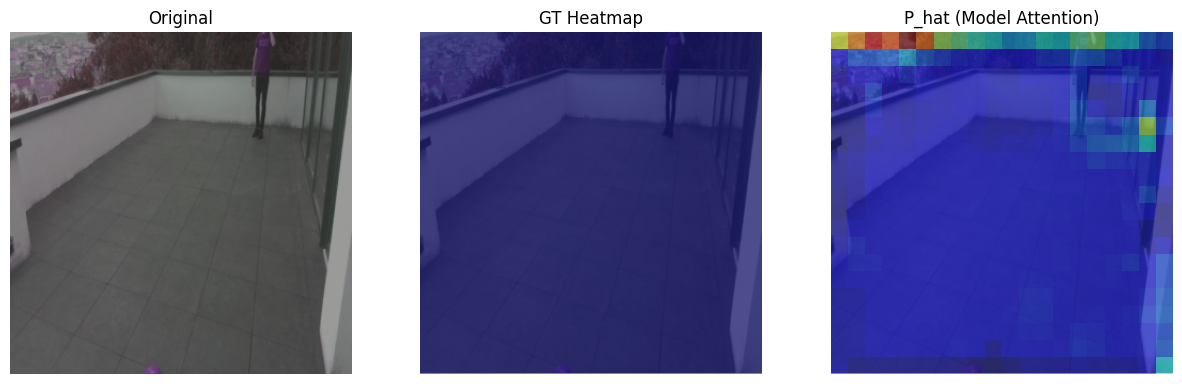

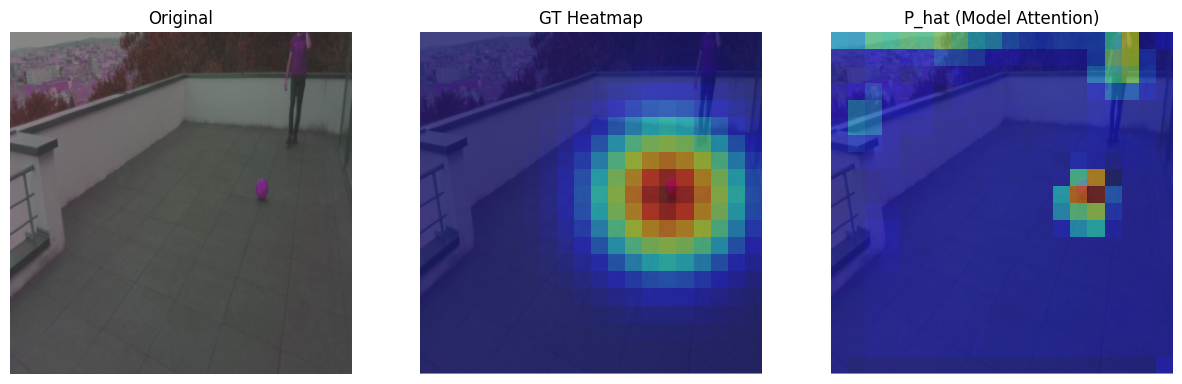

=== TRAINING ENDED ===


In [13]:
# ================= TRAIN =================
model = MoCA_BG_DETR().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = Criterion()

def train_one_epoch():
    model.train()
    total_loss = 0

    for img, prev, target in dataloader:
        img = img.to(DEVICE)
        prev = prev.to(DEVICE)

        outputs = model(img, prev)
        loss = criterion(outputs, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss

print("=== TRAINING STARTED ===")
for epoch in range(EPOCHS):
    start = time.time()

    loss = train_one_epoch()

    print(f"Epoch {epoch}: Loss={loss:.3f} | {(time.time()-start)/60:.2f} min")
    
visualize_predictions(model, dataloader)
print("=== TRAINING ENDED ===")

In [14]:
model.eval()

scripted = torch.jit.script(model)
scripted.save(MODEL_SAVE_PATH)

In [11]:
# ================= SAVE =================
torch.save(model, MODEL_SAVE_PATH)
print("Model saved.")

Model saved.
